# Практика 2 Оптимизация модели оттока
Я продолжаю практику 1 и загружаю сохранённую модель с теми же train и test. Для учебной бизнес-задачи считаю пропуск уходящего клиента более важной ошибкой, чем лишнее предупреждение. Цель — повысить recall класса «ушёл» примерно до 0,70. Для поиска использую F2: эта метрика учитывает precision, но придаёт recall больший вес.

In [1]:
from pathlib import Path
import platform
print("Python:", platform.python_version())
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# При запуске из корня проекта или из папки МО находятся одни и те же данные.
BASE = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd() / 'МО'
if not (BASE / 'data').is_dir():
    raise FileNotFoundError('Откройте ноутбук из папки МО или из папки Работы Николая.')
for folder in ['figures', 'results', 'models']:
    (BASE / folder).mkdir(exist_ok=True)
RANDOM_STATE = 42
plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 110})

def save_plot(name):
    # Сохраняю тот же график, который показывается в ноутбуке.
    plt.tight_layout()
    plt.savefig(BASE / 'figures' / name, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

def save_json(name, data):
    (BASE / 'results' / name).write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding='utf-8')

Python: 3.10.20


Исходная модель: DecisionTreeClassifier
              precision    recall  f1-score   support

     Остался       0.94      0.94      0.94       713
        Ушёл       0.67      0.67      0.67       121

    accuracy                           0.90       834
   macro avg       0.81      0.81      0.81       834
weighted avg       0.90      0.90      0.90       834



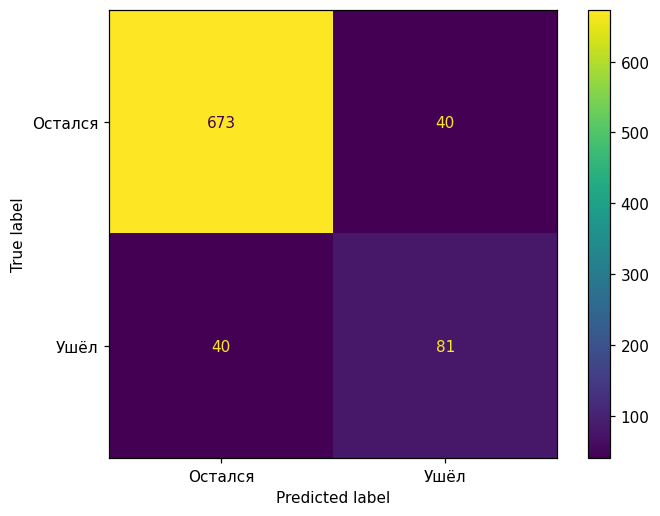

In [2]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, roc_auc_score, RocCurveDisplay, make_scorer, fbeta_score

with open(BASE / 'models' / 'practice1.pkl', 'rb') as f:
    previous = pickle.load(f)
old = previous['model']
X_train, X_test = previous['X_train'], previous['X_test']
y_train, y_test = previous['y_train'], previous['y_test']
old_pred = old.predict(X_test)
print('Исходная модель:', previous['model_name'])
print(classification_report(y_test, old_pred, target_names=['Остался', 'Ушёл']))
ConfusionMatrixDisplay.from_predictions(y_test,old_pred,display_labels=['Остался','Ушёл'])
save_plot('p2_before_confusion.png')

## Балансировка и поиск параметров
Дерево получило лучшую accuracy в первой практике. `class_weight='balanced'` увеличивает вес редкого класса при обучении. В GridSearchCV я перебираю глубину дерева и минимальное число клиентов в листе. Пять блоков CV создаются только из train, тест не участвует в подборе.

Лучшие параметры: {'model__criterion': 'entropy', 'model__max_depth': 8, 'model__min_samples_leaf': 5}
Средний F2 на CV: 0.7629
              precision    recall  f1-score   support

     Остался       0.95      0.94      0.95       713
        Ушёл       0.69      0.73      0.71       121

    accuracy                           0.91       834
   macro avg       0.82      0.84      0.83       834
weighted avg       0.91      0.91      0.91       834



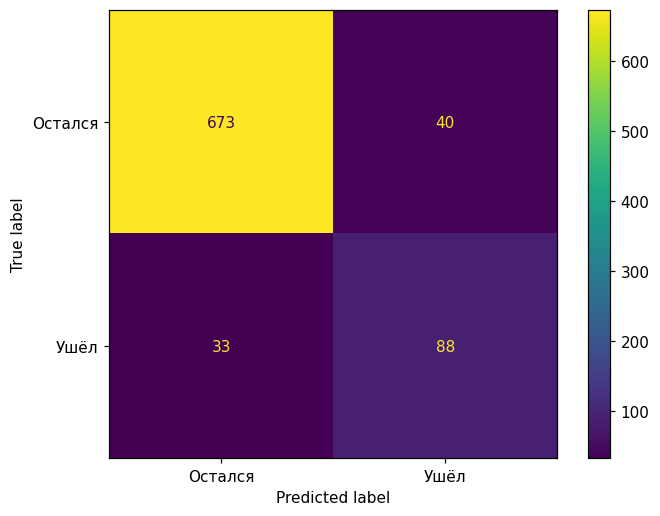

In [3]:
pipe = clone(old)
pipe.set_params(model__class_weight='balanced')
param_grid = {'model__max_depth': [3, 5, 8, 10, None],
              'model__min_samples_leaf': [1, 5, 10, 20],
              'model__criterion': ['gini', 'entropy']}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid, scoring=make_scorer(fbeta_score, beta=2), cv=cv, n_jobs=1)
grid.fit(X_train, y_train)
print('Лучшие параметры:', grid.best_params_)
print('Средний F2 на CV:', round(grid.best_score_, 4))
# GridSearchCV уже обучил best_estimator_ на всём train через refit=True.
best = grid.best_estimator_
pred = best.predict(X_test)
print(classification_report(y_test, pred, target_names=['Остался', 'Ушёл']))
ConfusionMatrixDisplay.from_predictions(y_test,pred,display_labels=['Остался','Ушёл'])
save_plot('p2_after_confusion.png')

## Сравнение и важность признаков
ROC-кривая показывает результат при разных порогах. AUC оценивает ранжирование клиентов по риску ухода. Важность дерева показывает, какие признаки использовались для разделений, но не доказывает причинное влияние на отток.

,Модель,Accuracy,Precision ушёл,Recall ушёл,F1 ушёл,AUC
0,Исходная,0.904077,0.669421,0.669421,0.669421,0.806660
1,Оптимизированная,0.912470,0.687500,0.727273,0.706827,0.824609


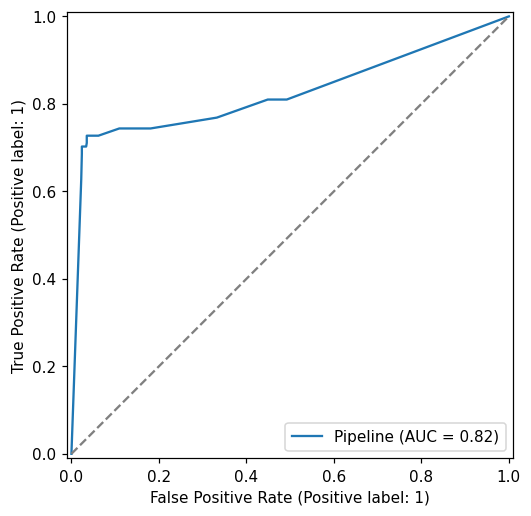

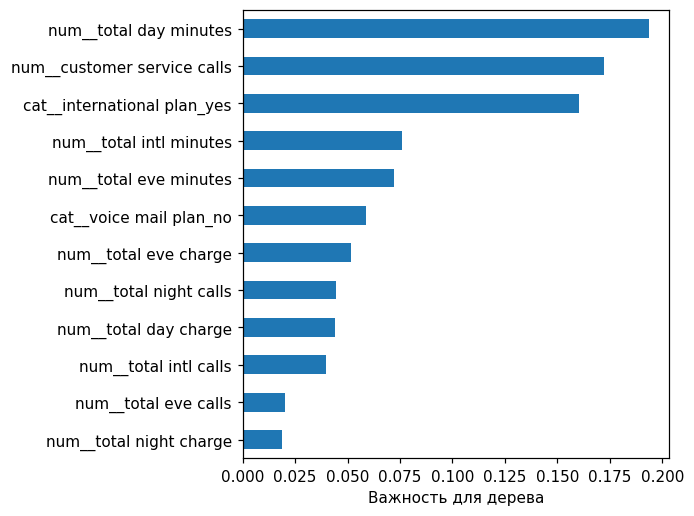

Цель recall 0,70 достигнута: True
Изменение recall: 0.0579
Изменение F1: 0.0374


In [4]:
rows = []
for name, model in [('Исходная', old), ('Оптимизированная', best)]:
    labels = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    rows.append({'Модель': name, 'Accuracy': accuracy_score(y_test, labels),
                 'Precision ушёл': precision_score(y_test, labels),
                 'Recall ушёл': recall_score(y_test, labels),
                 'F1 ушёл': f1_score(y_test, labels), 'AUC': roc_auc_score(y_test, probabilities)})
results = pd.DataFrame(rows)
display(results)
results.to_csv(BASE / 'results' / 'practice2.csv', index=False)
RocCurveDisplay.from_estimator(best, X_test, y_test)
plt.plot([0,1],[0,1],linestyle='--',color='grey')
save_plot('p2_roc.png')
names = best.named_steps['preprocess'].get_feature_names_out()
importance = pd.Series(best.named_steps['model'].feature_importances_,index=names).sort_values().tail(12)
importance.plot.barh()
plt.xlabel('Важность для дерева')
save_plot('p2_importance.png')
with open(BASE / 'models' / 'practice2.pkl', 'wb') as f:
    pickle.dump(best, f)
new_recall = recall_score(y_test,pred)
print('Цель recall 0,70 достигнута:', new_recall >= 0.70)
print('Изменение recall:', round(new_recall-recall_score(y_test,old_pred),4))
print('Изменение F1:', round(f1_score(y_test,pred)-f1_score(y_test,old_pred),4))
save_json('practice2.json', {'best_params': grid.best_params_, 'cv_f2': grid.best_score_,
                            'recall_target_met': bool(new_recall>=0.70)})

## Вывод
На сохранённом тесте accuracy выросла с 0,904 до 0,912, precision класса «ушёл» — с 0,669 до 0,688, recall — с 0,669 до 0,727, F1 — с 0,669 до 0,707, AUC — с 0,807 до 0,825. Цель recall не ниже 0,70 достигнута. В этом эксперименте все перечисленные показатели улучшились. При этом высокая оценка на одном тесте не гарантирует такой же результат на любых новых клиентах. Критерий поиска F2 выбран из-за приоритета полноты.